# Modelación en ingeniería
## Neural Ordinary Differential Equiations

*Profesor: David Ortiz-Puerta*

---

> **💡 Nota para usuarios de Google Colab**  
> Antes de ejecutar el notebook, instala la librería necesaria descomentando y ejecutando la siguiente celda.

In [ ]:
# !wget -q https://raw.githubusercontent.com/dortiz5/modelacion-en-ingenieria/main/Notebooks/helpers.py
# !pip install torchdiffeq

### 1 Librerías y configuración

Usamos `PyTorch` como framework de redes neuronales y `torchdiffeq` para la integración de la EDO con propagación de gradientes (método adjunto). La línea `device = ...` selecciona GPU si está disponible; en caso contrario, el código corre en CPU sin cambios.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from helpers import configure_plot_style
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

configure_plot_style()

cuda


### 2. Generación de datos

Simulamos un péndulo no lineal con fricción y muestreamos varias trayectorias desde distintas condiciones iniciales. Estos ensayos serán los datos de entrenamiento: el identificador no conoce la ecuación ni los parámetros, solo dispone de las trayectorias medidas.

El péndulo no lineal con fricción viscosa se describe mediante una EDO de segundo orden:

$$\ddot{\theta} + b\,\dot{\theta} + \frac{g}{L}\sin\theta = 0$$

Definiendo los estados $x_1 = \theta$ (ángulo) y $x_2 = \dot{\theta}$ (velocidad angular), se reescribe como un sistema de dos EDOs de primer orden:

$$\dot{x}_1 = x_2$$
$$\dot{x}_2 = -b\,x_2 - \frac{g}{L}\sin(x_1)$$

El vector de estado es $\mathbf{x}(t) = [x_1(t),\, x_2(t)]^\top \in \mathbb{R}^2$, que concentra toda la información necesaria para propagar el sistema hacia adelante en el tiempo.

### Conexión con la Neural ODE

Una Neural ODE reemplaza la función dinámica conocida $f(\mathbf{x})$ por una red neuronal $f_\theta(\mathbf{x})$, cuya salida es la derivada del estado:

$$\frac{d\mathbf{x}}{dt} = f_\theta(\mathbf{x})$$

El identificador **no conoce** la ecuación del péndulo ni los parámetros $(g, L, b)$: solo dispone de trayectorias medidas $\{\mathbf{x}(t_k)\}$. El entrenamiento ajusta los pesos $\theta$ de la red para que, al integrar $f_\theta$ desde una condición inicial, las trayectorias predichas sean consistentes con los datos observados.

In [11]:
# --- Modelo: péndulo no lineal con fricción ---
g, L, b = 9.81, 9.81, 0.3      # parámetros canónicos (desconocidos para el identificador)

def pendulum(t, x):
    theta, omega = x
    return [omega, -b*omega - (g/L)*np.sin(theta)]

# --- Configuración de simulación ---
t_span = (0.0, 10.0)
dt     = 0.05
t      = np.arange(t_span[0], t_span[1], dt)
sigma  = 0.00                  # desv. est. del ruido de medición

# --- Múltiples ensayos: distintas condiciones iniciales ---
# Cada ensayo parte de un (theta0, omega0) distinto para cubrir el espacio de fase
n_traj = 10
rng    = np.random.default_rng(0)
theta0 = rng.uniform(-np.pi, np.pi, n_traj)     # ángulo inicial
omega0 = rng.uniform(-2.0, 2.0, n_traj)         # velocidad inicial

# --- Simulación de cada trayectoria ---
# Se integra la EDO para cada CI y se le agrega ruido de medición
trajectories = []
for k in range(n_traj):
    sol = solve_ivp(pendulum, t_span, [theta0[k], omega0[k]], t_eval=t)
    X   = sol.y.T                                # (len(t), 2): columnas [theta, omega]
    X_noisy = X + sigma*rng.standard_normal(X.shape)
    trajectories.append(X_noisy)

trajectories = np.array(trajectories)            # (n_traj, len(t), 2)
print(f"Generadas {n_traj} trayectorias, cada una de {len(t)} puntos.")

Generadas 10 trayectorias, cada una de 200 puntos.


> **💡 Nota**  
> Antes de definir la red, los datos se convierten a tensores de PyTorch mediante `torch.tensor(..., dtype=torch.float32).to(device)`. Esta conversión es necesaria porque PyTorch opera sobre tensores, no sobre arreglos de NumPy. El argumento `dtype=torch.float32` especifica precisión simple, suficiente para entrenamiento en GPU. El método `.to(device)` mueve los datos al dispositivo seleccionado (CPU o GPU) de forma automática.

In [12]:
# --- Conversión a tensores de PyTorch ---
t_tensor = torch.tensor(t, dtype=torch.float32).to(device)
X_tensor = torch.tensor(trajectories, dtype=torch.float32).to(device)  # Shape: (10, 200, 2)

### 3. Red neuronal como campo vectorial

En esta etapa se define una red neuronal que actúa como aproximador del campo vectorial de la EDO. La función desconocida $\mathbf{f}$ se reemplaza por una red dependiente de un conjunto de parámetros $\theta$:

$$
\dot{\mathbf{x}} = \mathbf{f}_{NN}(\mathbf{x}; \theta) \approx \mathbf{f}(\mathbf{x}).
$$

Los parámetros del modelo corresponden a los pesos y sesgos de cada capa de la red, que se agrupan como:

$$
\theta = \{ W_i, b_i \}_{i=1}^{L},
$$

donde $W_i$ y $b_i$ representan los pesos y sesgos de la capa $i$, respectivamente, y $L$ es el número total de capas. Estos parámetros se ajustan durante el entrenamiento con el objetivo de minimizar el error entre las trayectorias predichas y las observadas.

La arquitectura de la red se define mediante la lista `hidden_layers`, que especifica el número de neuronas en cada capa de entrada a salida. El constructor de la clase recorre esa lista y ensambla la red capa por capa:

- `nn.Linear(m, n)` implementa la transformación afín $h = Wx + b$, con $W \in \mathbb{R}^{n \times m}$ y $b \in \mathbb{R}^n$. Es la operación de combinación lineal vista en la presentación.
- `nn.Tanh()` aplica la función de activación $\sigma(z) = \tanh(z)$ elemento a elemento. Se eligió *tanh* porque es suave y diferenciable en todo su dominio, propiedades necesarias para que el campo vectorial aprendido sea físicamente razonable.
- `nn.Sequential` encadena las capas en orden: la salida de cada una es la entrada de la siguiente, implementando directamente la composición $f^{(L)} \circ \cdots \circ f^{(1)}(x)$ de la presentación.

> **💡 Nota**  
> La última capa de la red no tiene función de activación (es lineal). Esto es intencional: la derivada del estado $\dot{\mathbf{x}}$ puede tomar cualquier valor real, sin restricciones de rango. Si se aplicara `Tanh` en la última capa, la salida quedaría acotada en $(-1, 1)$, lo que limitaría incorrectamente los valores que puede representar el campo vectorial.

En el método `forward(self, t, x)`, el argumento `t` es requerido por `odeint` aunque el sistema sea autónomo (no depende explícitamente del tiempo). La red solo utiliza `x` para computar la derivada.

> **💡 Nota**  
> La inicialización de Xavier (`xavier_normal_`) distribuye los pesos iniciales de forma que la varianza de las activaciones se mantenga estable a lo largo de las capas. Esto acelera la convergencia y evita que los gradientes se anulen o exploten al inicio del entrenamiento.

In [13]:
# --- Definición de la Red Neuronal ---
# Esta red representa el campo vectorial f_NN(x): recibe el estado y devuelve su derivada
class NeuralNetwork(nn.Module):
    def __init__(self, hlayers):
        super(NeuralNetwork, self).__init__()
        # Construye capas ocultas con activación Tanh; la última capa es lineal
        layers = []
        for i in range(len(hlayers[:-2])):
            layers.append(nn.Linear(hlayers[i], hlayers[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hlayers[-2], hlayers[-1])) # última capa

        self.layers = nn.Sequential(*layers)
        self.init_params()

    def init_params(self):
        # Inicialización Xavier en los pesos de cada capa lineal
        def init_normal(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
        self.apply(init_normal)

    # odeint exige la firma f(t, x), aunque el campo no dependa explícitamente de t (sistema autónomo)
    def forward(self, t, x):
        return self.layers(x)

```python
hidden_layers = [2, 10, 10, 2]
```

Cada elemento de la lista corresponde a una capa:

| Posición | Valor | Significado |
|----------|-------|-------------|
| `hidden_layers[0]` | `2` | Capa de entrada: dimensión del estado $\mathbf{x} = (\theta, \omega)$ |
| `hidden_layers[1]` | `10` | Primera capa oculta: 10 neuronas |
| `hidden_layers[2]` | `10` | Segunda capa oculta: 10 neuronas |
| `hidden_layers[-1]` | `2` | Capa de salida: dimensión de $\dot{\mathbf{x}} = (\dot{\theta}, \dot{\omega})$ |

El `2` inicial y el `2` final no son coincidencia: la red recibe el estado del sistema y devuelve su derivada, que tiene exactamente la misma dimensión. En general, para un sistema de $n$ estados la lista debe comenzar y terminar en $n$.

In [14]:
torch.manual_seed(123)

# Arquitectura: entrada 2 (estado), dos capas ocultas de 10, salida 2 (derivada del estado)
hidden_layers = [2, 10, 10, 2]

model  = NeuralNetwork(hidden_layers).to(device)
nparams = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of trainable parameters: {nparams}')

Number of trainable parameters: 162


### 4. Entrenamiento

El entrenamiento ajusta los parámetros $\theta$ minimizando el error entre las trayectorias predichas y las observadas:

$$
\mathcal{L}(\theta) = \frac{1}{N \cdot T}\sum_{k=1}^{N}\sum_{i=1}^{T} \|\mathbf{x}_k(t_i) - \hat{\mathbf{x}}_k(t_i;\theta)\|^2
$$

donde $N$ es el número de trayectorias y $T$ el número de instantes por trayectoria.

Antes del bucle se preparan dos objetos:

- `x0_full`: condiciones iniciales de shape `(N, 2)`, una por trayectoria.
- `target_full`: datos reordenados a shape `(T, N, 2)` para coincidir con el formato de salida de `odeint`, que devuelve el tiempo en el primer eje.

Cada iteración sigue el esquema de la presentación:

1. `zero_grad()` — limpia gradientes del paso anterior.
2. `odeint(..., method='rk4')` — *forward pass*: integra la EDO definida por la red desde todas las condiciones iniciales en paralelo.
3. `loss_fn(prediction, target_full)` — evalúa el MSE.
4. `loss.backward()` — *backward pass*: propaga gradientes a través del integrador.
5. `optimizer.step()` — actualiza $\theta$ con Adam.

> **💡 Nota**  
> Los instantes $t_k$ son puntos de *evaluación*: el integrador resuelve $d\mathbf{x}/dt = f_\theta(\mathbf{x})$ internamente, por lo que la consistencia con la EDO queda garantizada por construcción, no impuesta como restricción explícita.

> **💡 Nota**  
> Se usa RK4 (paso fijo) en lugar de un solver adaptativo para garantizar que los puntos de evaluación coincidan exactamente con `t_tensor`. Los gradientes fluyen a través del integrador gracias a `torchdiffeq`.

In [15]:
# 3. Preparación de datos para integración de trayectoria
# Extraemos los 12 estados iniciales. Shape: (12, 2)
# odeint integrará la EDO desde cada x0 a lo largo de t_tensor, simultáneamente para las 12 trayectorias
x0_full     = X_tensor[:, 0, :]
target_full = X_tensor.transpose(0, 1)        # (200, 12, 2): odeint devuelve tiempo en el eje 0

# 4. Bucle de Entrenamiento
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn   = nn.MSELoss()
epochs    = 1000

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # Forward: integramos la EDO definida por la red desde cada x0 en paralelo
    # 'rk4' es un solver de paso fijo; método explícito Runge-Kutta de orden 4
    prediction = odeint(model, x0_full, t_tensor, method='rk4')

    # Cálculo de pérdida y retropropagación
    # MSE entre trayectorias predichas y medidas (sobre todos los tiempos y trayectorias)
    loss = loss_fn(prediction, target_full)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:04d} | Loss: {loss.item():.6f}")

Epoch 0050 | Loss: 0.379679
Epoch 0100 | Loss: 0.223012
Epoch 0150 | Loss: 0.195952
Epoch 0200 | Loss: 0.174795
Epoch 0250 | Loss: 0.156908
Epoch 0300 | Loss: 0.143712
Epoch 0350 | Loss: 0.134892
Epoch 0400 | Loss: 0.128195
Epoch 0450 | Loss: 0.121580
Epoch 0500 | Loss: 0.113397
Epoch 0550 | Loss: 0.100314
Epoch 0600 | Loss: 0.074644
Epoch 0650 | Loss: 0.038553
Epoch 0700 | Loss: 0.017886
Epoch 0750 | Loss: 0.013176
Epoch 0800 | Loss: 0.010081
Epoch 0850 | Loss: 0.007653
Epoch 0900 | Loss: 0.005647
Epoch 0950 | Loss: 0.004308
Epoch 1000 | Loss: 0.003222


### 5. Validación

Una vez entrenada la red, se evalúa su capacidad para reproducir la dinámica desde una condición inicial nueva, no vista durante el entrenamiento. Se compara la trayectoria predicha por la NODE contra la solución del modelo físico real (sin ruido).

La comparación se realiza en dos niveles: el comportamiento temporal de $\theta(t)$ y $\omega(t)$, y el campo vectorial aprendido frente al real en el plano de fase. Esto permite ver no solo qué tan bien predice la red, sino *por qué*: si el campo aprendido se parece al real en la región explorada por los datos, la predicción será buena para cualquier condición inicial dentro de esa región.

> **💡 Nota**  
> NODEs aprende el campo vectorial únicamente en la región del espacio de estados que los datos exploran. Fuera de esa región, el campo aprendido no tiene información que lo restrinja y puede diferir arbitrariamente del real.

MSE en validación: 0.006822


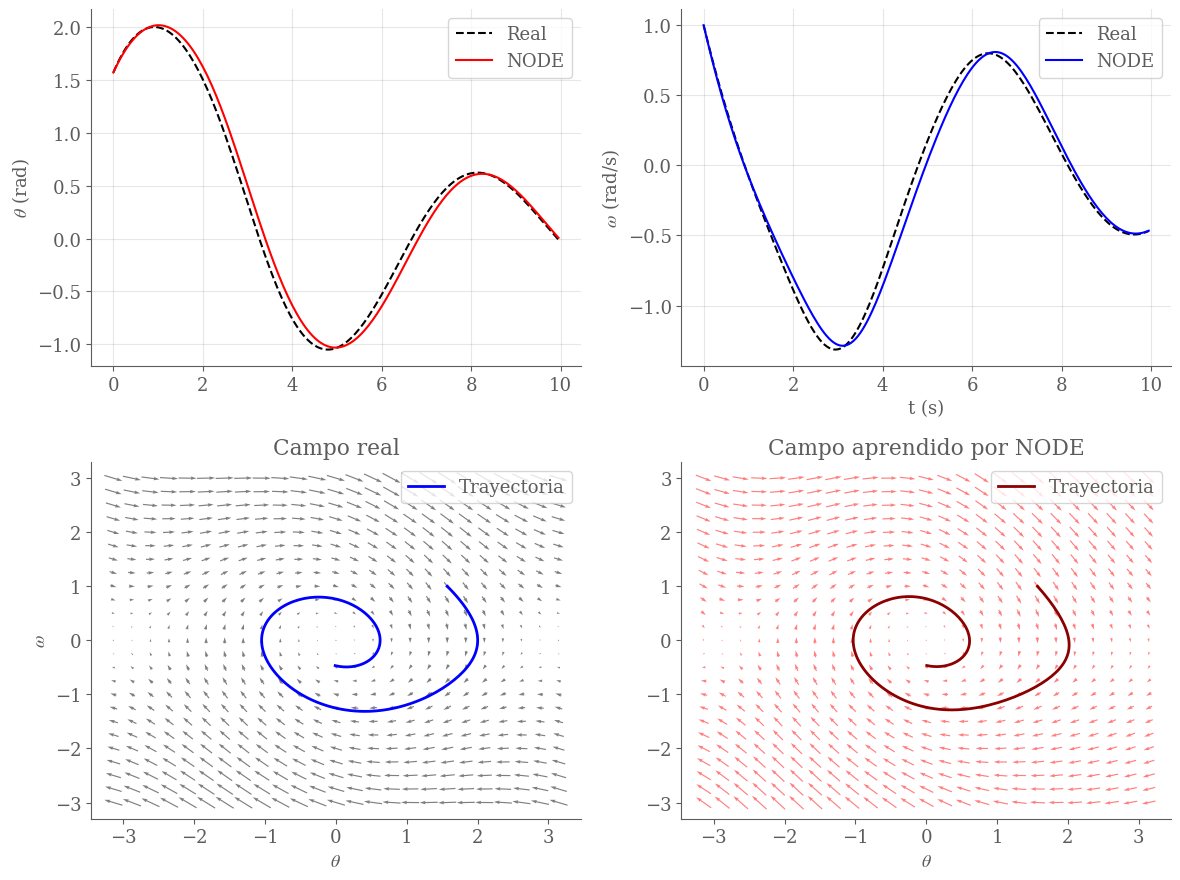

In [19]:
# === Validación: predicción vs física real ===

# CI fuera de la distribución de entrenamiento (omega0 > 2.0)
x0_test_np = np.array([np.pi/2, 1])

# Ground truth: integración del modelo físico real (sin ruido)
X_true = solve_ivp(pendulum, t_span, x0_test_np, t_eval=t).y.T

# Predicción del modelo NODE
model.eval()
with torch.no_grad():
    x0_test = torch.tensor(x0_test_np, dtype=torch.float32).to(device).unsqueeze(0)
    X_pred  = odeint(model, x0_test, t_tensor, method='rk4').squeeze(1).cpu().numpy()

mse_test = np.mean((X_true - X_pred)**2)
print(f"MSE en validación: {mse_test:.6f}")

# === Campo vectorial aprendido vs real (retrato de fase) ===

# Cuadrícula del espacio de fase
theta_vals = np.linspace(-np.pi, np.pi, 25)
omega_vals = np.linspace(-3.0, 3.0, 25)
Theta, Omega = np.meshgrid(theta_vals, omega_vals)

# Campo real
U_true = Omega
V_true = -b*Omega - (g/L)*np.sin(Theta)

# Campo aprendido por la red (sistema autónomo: t arbitrario)
grid_tensor = torch.tensor(np.vstack([Theta.ravel(), Omega.ravel()]).T,
                           dtype=torch.float32).to(device)
with torch.no_grad():
    d_pred = model(torch.tensor(0.0).to(device), grid_tensor).cpu().numpy()
U_pred = d_pred[:, 0].reshape(Theta.shape)
V_pred = d_pred[:, 1].reshape(Omega.shape)

# === Visualización 2x2 ===
fig, ax = plt.subplots(2, 2, figsize=(12, 9))

# Fila superior: comportamiento en el tiempo
ax[0,0].plot(t, X_true[:, 0], 'k--', label='Real')
ax[0,0].plot(t, X_pred[:, 0], 'r',   label='NODE')
ax[0,0].set_ylabel(r'$\theta$ (rad)'); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

ax[0,1].plot(t, X_true[:, 1], 'k--', label='Real')
ax[0,1].plot(t, X_pred[:, 1], 'b',   label='NODE')
ax[0,1].set_ylabel(r'$\omega$ (rad/s)'); ax[0,1].set_xlabel('t (s)')
ax[0,1].legend(); ax[0,1].grid(alpha=0.3)

# Fila inferior: retrato de fase (campo + trayectoria de validación)
ax[1,0].quiver(Theta, Omega, U_true, V_true, color='black', alpha=0.5, pivot='mid')
ax[1,0].plot(X_true[:, 0], X_true[:, 1], 'b', lw=2, label='Trayectoria')
ax[1,0].set_title('Campo real')
ax[1,0].set_xlabel(r'$\theta$'); ax[1,0].set_ylabel(r'$\omega$'); ax[1,0].legend()

ax[1,1].quiver(Theta, Omega, U_pred, V_pred, color='red', alpha=0.5, pivot='mid')
ax[1,1].plot(X_pred[:, 0], X_pred[:, 1], 'darkred', lw=2, label='Trayectoria')
ax[1,1].set_title('Campo aprendido por NODE')
ax[1,1].set_xlabel(r'$\theta$'); ax[1,1].legend()

plt.tight_layout(); plt.show()

### Ejercicio propuesto: Lotka-Volterra

Aplique el mismo procedimiento al sistema presa-depredador de Lotka-Volterra:

$$
\dot{x}_1 = \alpha x_1 - \beta x_1 x_2, \qquad \dot{x}_2 = \delta x_1 x_2 - \gamma x_2
$$

donde $x_1$ representa la población de presas y $x_2$ la de depredadores.

**Tareas:**

1. Genere múltiples trayectorias con distintas condiciones iniciales que cubran una región del plano $(x_1, x_2)$. Considere que las órbitas del sistema sin fricción son cerradas: una sola trayectoria no basta para cubrir el espacio de fase.
2. Entrene una NODE para aprender el campo vectorial $\mathbf{f}_{NN}(x_1, x_2; \theta)$.
3. Valide con una condición inicial nueva y compare el campo vectorial aprendido con el real.

**Preguntas para discusión:**

- ¿Cuántas trayectorias son suficientes para que la NODE reconstruya el retrato de fase?
- ¿Qué ocurre si se entrena con una única trayectoria? ¿La red generaliza a otras órbitas?
- ¿Cómo cambia el resultado si solo se observa una de las dos especies?